# Distribution basics

*If you haven't read the [Getting Started tutorial](../tutorials/getting_started.ipynb),
read it first. This notebook zooms in on `Distribution` — the first of
ProbPipe's three core types.*

A `Distribution` is a value-like object that packages a random variable
together with the operations you can perform on it — sampling, density
evaluation, moments, and so on. Every distribution in ProbPipe exposes
the same surface through the public ops:

| Op | Meaning |
|---|---|
| `sample(dist, key=..., sample_shape=...)` | Draw samples |
| `log_prob(dist, x)` | Log density (or log mass) at `x` |
| `prob(dist, x)` | Density at `x` — i.e. `exp(log_prob)` |
| `mean(dist)` | `E[X]` |
| `variance(dist)` | `Var[X]` per element |
| `cov(dist)` | Covariance matrix (multivariate only) |
| `expectation(dist, f, ...)` | `E[f(X)]` — exact when possible, MC otherwise |

Not every distribution supports every operation. An MCMC posterior can be
sampled but has no closed-form density; a Gaussian random function has a
density but no finite-dimensional sample. ProbPipe makes these
distinctions explicit through **protocols** — `@runtime_checkable`
interfaces that each distribution class opts into:

| Protocol | Op | Meaning |
|---|---|---|
| `SupportsSampling` | `sample` | Can draw samples |
| `SupportsLogProb` | `log_prob` / `prob` | Has a density or mass function |
| `SupportsMean` | `mean` | Can compute its mean |
| `SupportsVariance` | `variance` | Can compute its variance |
| `SupportsCovariance` | `cov` | Can compute its covariance matrix |
| `SupportsConditioning` | `condition_on` | Supports exact conditioning |
| `SupportsExpectation` | `expectation` | Supports `E[f(X)]` (exact or MC) |

Every public op checks the relevant protocol at dispatch time, so calling
`log_prob` on something that doesn't support it raises with a clear
error rather than silently producing NaN.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal,
    Beta,
    Gamma,
    Exponential,
    MultivariateNormal,
    Dirichlet,
    Poisson,
    Categorical,
    Bernoulli,
    NumericEmpiricalDistribution,
    sample,
    log_prob,
    prob,
    mean,
    variance,
    cov,
    expectation,
)
from probpipe.core.protocols import (
    SupportsSampling,
    SupportsLogProb,
    SupportsMean,
    SupportsVariance,
    SupportsCovariance,
    SupportsExpectation,
)

key = jax.random.PRNGKey(0)

## 1. Parametric families

ProbPipe ships the usual parametric distributions, each with the
familiar constructor arguments. Every construction requires `name=` —
the name propagates through ops and is useful for provenance /
diagnostics.

In [2]:
n = Normal(loc=2.0, scale=0.5, name="n")
b = Beta(alpha=2.0, beta=5.0, name="b")
g = Gamma(concentration=3.0, rate=1.0, name="g")

for dist in [n, b, g]:
    print(f"{dist}")
    print(f"  event_shape={dist.event_shape}, batch_shape={dist.batch_shape}")
    print(f"  mean={float(mean(dist)):.4f}, var={float(variance(dist)):.4f}")

Normal(name='n', event_shape=())
  event_shape=(), batch_shape=()
  mean=2.0000, var=0.2500
Beta(name='b', event_shape=())
  event_shape=(), batch_shape=()
  mean=0.2857, var=0.0255
Gamma(name='g', event_shape=())
  event_shape=(), batch_shape=()
  mean=3.0000, var=3.0000


## 2. Sampling

`sample(dist, key=..., sample_shape=...)` draws from the distribution.
The output shape is `sample_shape + batch_shape + event_shape`. The
`key` argument is optional — when omitted, ProbPipe derives one from a
deterministic per-session counter, so your output is reproducible
within a single interpreter run.

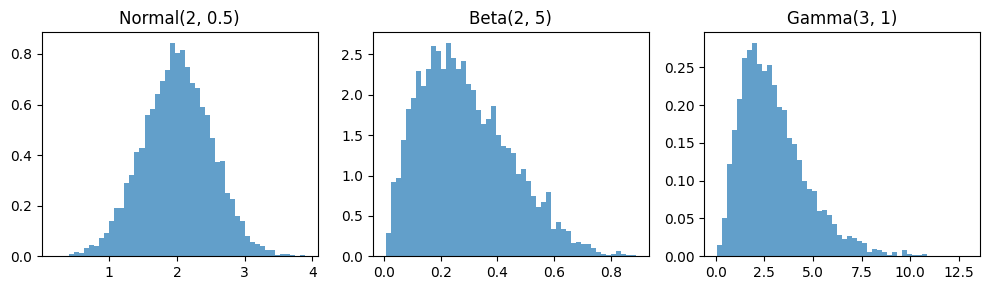

In [3]:
k1, k2, k3 = jax.random.split(key, 3)
samples_n = sample(n, key=k1, sample_shape=(5000,))
samples_b = sample(b, key=k2, sample_shape=(5000,))
samples_g = sample(g, key=k3, sample_shape=(5000,))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, s, title in zip(axes, [samples_n, samples_b, samples_g],
                        ["Normal(2, 0.5)", "Beta(2, 5)", "Gamma(3, 1)"]):
    ax.hist(np.asarray(s), bins=50, density=True, alpha=0.7)
    ax.set_title(title)
plt.tight_layout(); plt.show()

Discrete distributions work the same way — a `Poisson` returns integer
counts, a `Categorical` returns class indices.

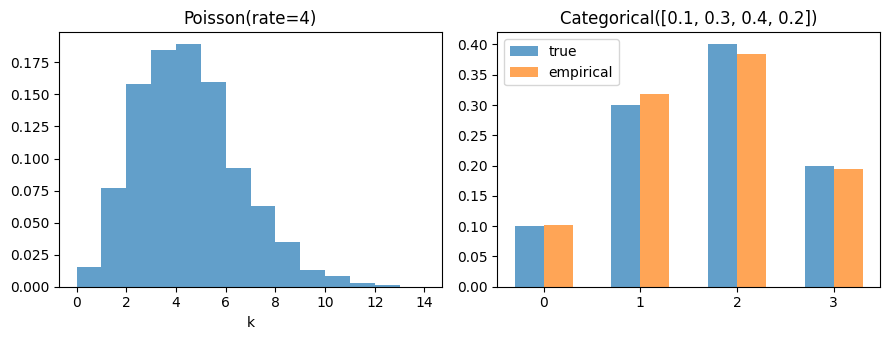

In [4]:
p = Poisson(rate=4.0, name="p")
cat = Categorical(probs=jnp.array([0.1, 0.3, 0.4, 0.2]), name="cat")
samples_p = sample(p, key=jax.random.PRNGKey(3), sample_shape=(1000,))
samples_c = sample(cat, key=jax.random.PRNGKey(4), sample_shape=(1000,))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.hist(np.asarray(samples_p), bins=range(15), density=True, alpha=0.7)
ax1.set_title("Poisson(rate=4)"); ax1.set_xlabel("k")

classes = jnp.arange(4)
empirical = jnp.array([(samples_c == k).sum() for k in classes]) / 1000.0
ax2.bar(classes - 0.15, cat.probs, width=0.3, label="true", alpha=0.7)
ax2.bar(classes + 0.15, empirical, width=0.3, label="empirical", alpha=0.7)
ax2.set_xticks(classes); ax2.set_title("Categorical([0.1, 0.3, 0.4, 0.2])")
ax2.legend()
plt.tight_layout(); plt.show()

## 3. Density and probability

`log_prob(dist, x)` returns the log-density (for continuous distributions)
or log-mass (for discrete ones). `prob` is the non-log convenience
wrapper. Both vectorise automatically over extra leading dimensions.

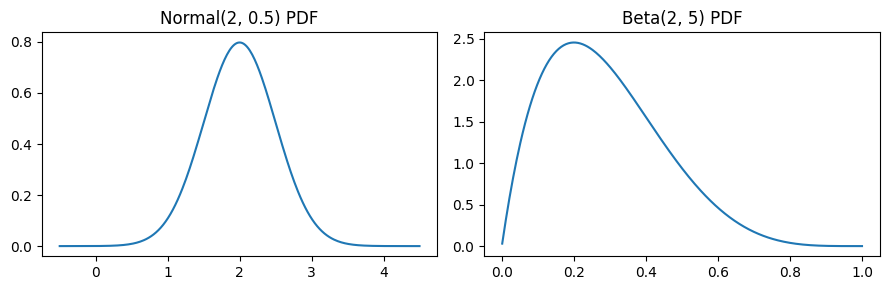

In [5]:
x = jnp.linspace(-0.5, 4.5, 300)
xb = jnp.linspace(0.001, 0.999, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(x, prob(n, x)); ax1.set_title("Normal(2, 0.5) PDF")
ax2.plot(xb, prob(b, xb)); ax2.set_title("Beta(2, 5) PDF")
plt.tight_layout(); plt.show()

## 4. Multivariate distributions

`MultivariateNormal` and `Dirichlet` are the workhorses. `MultivariateNormal`
takes a covariance (`cov=`) or lower-triangular Cholesky factor
(`scale_tril=`); `Dirichlet` lives on the probability simplex.

MultivariateNormal(name='mvn', event_shape=(2,))
  event_shape=(2,), mean=[ 1. -1.]
  cov:
[[1.        0.5      ]
 [0.5       1.9999999]]


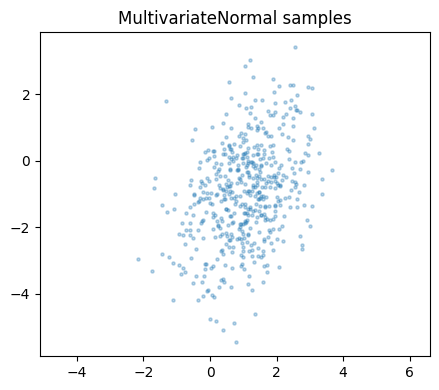

In [6]:
mvn = MultivariateNormal(
    loc=jnp.array([1.0, -1.0]),
    cov=jnp.array([[1.0, 0.5], [0.5, 2.0]]),
    name="mvn",
)
print(mvn)
print(f"  event_shape={mvn.event_shape}, mean={mean(mvn)}")
print(f"  cov:\n{cov(mvn)}")

samples_mvn = sample(mvn, key=jax.random.PRNGKey(5), sample_shape=(500,))
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(np.asarray(samples_mvn[:, 0]), np.asarray(samples_mvn[:, 1]),
           alpha=0.3, s=5)
ax.set_title("MultivariateNormal samples"); ax.axis("equal")
plt.tight_layout(); plt.show()

Dirichlet(name='d', event_shape=(3,))
  event_shape=(3,), mean=[0.25  0.625 0.125]


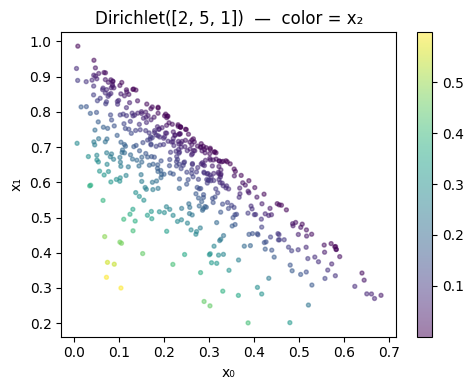

In [7]:
d = Dirichlet(concentration=jnp.array([2.0, 5.0, 1.0]), name="d")
print(d)
print(f"  event_shape={d.event_shape}, mean={mean(d)}")
samples_d = sample(d, key=jax.random.PRNGKey(7), sample_shape=(500,))

fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(np.asarray(samples_d[:, 0]), np.asarray(samples_d[:, 1]),
                c=np.asarray(samples_d[:, 2]), alpha=0.5, s=8, cmap="viridis")
ax.set_xlabel("x₀"); ax.set_ylabel("x₁")
ax.set_title("Dirichlet([2, 5, 1])  —  color = x₂")
plt.colorbar(sc); plt.tight_layout(); plt.show()

## 5. Expectations with `expectation`

`mean` and `variance` give you `E[X]` and `Var[X]`. For anything else —
`E[sin(X)]`, `E[X**3]`, `E[f(X)]` for arbitrary `f` — use
`expectation(dist, f, ...)`. When the distribution's support is finite
(e.g. `Categorical`), the result is exact. Otherwise it's a
Monte Carlo estimate, returned by default as a `BootstrapDistribution`
that captures the MC sampling error.

In [8]:
from probpipe import BootstrapDistribution

# MC estimate with returned-distribution error tracking
ex_sin = expectation(
    n, lambda x: jnp.sin(x),
    key=jax.random.PRNGKey(10), num_evaluations=5000,
)
print(f"E[sin(N(2, 0.5))] (MC, 5000 draws):")
print(f"  point estimate:  {float(mean(ex_sin)):.4f}")
print(f"  MC std error:    {float(jnp.sqrt(variance(ex_sin))):.4f}")
print(f"  returned type:   {type(ex_sin).__name__}")

E[sin(N(2, 0.5))] (MC, 5000 draws):
  point estimate:  0.8000


  MC std error:    0.0033
  returned type:   BootstrapDistribution


In [9]:
# Exact expectation on a finite-support distribution — no MC needed
ex_cat = expectation(cat, lambda x: x ** 2)
print(f"\nE[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = {float(ex_cat):.3f}")
print(f"  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = {0*.1 + 1*.3 + 4*.4 + 9*.2:.3f}")
print(f"  returned type: {type(ex_cat).__name__}  (raw array, not a BootstrapDistribution)")


E[X^2] for Categorical([0.1, 0.3, 0.4, 0.2]) = 3.700
  by hand: 0*.1 + 1*.3 + 4*.4 + 9*.2 = 3.700
  returned type: ArrayImpl  (raw array, not a BootstrapDistribution)


In [10]:
# Turn off the error-bar wrapping with return_dist=False
ex_plain = expectation(
    n, lambda x: jnp.sin(x),
    key=jax.random.PRNGKey(10), num_evaluations=5000,
    return_dist=False,
)
print(f"\nreturn_dist=False: {float(ex_plain):.4f}  (plain {type(ex_plain).__name__})")


return_dist=False: 0.8000  (plain ArrayImpl)


## 6. `NumericEmpiricalDistribution` — wrapping samples as a distribution

When you already have a batch of draws (MCMC output, imported data,
simulated replicates), `NumericEmpiricalDistribution` wraps them as a
first-class distribution. It supports sampling (by resampling the stored
points), moments, and covariance, but *not* `log_prob` — an empirical
sample has no density. See the converting-representations notebook for
how to turn it into a density-bearing distribution when you need one.

In [11]:
raw = (
    jax.random.normal(jax.random.PRNGKey(8), (200, 2))
    * jnp.array([1.0, 3.0])
    + jnp.array([2.0, -1.0])
)
emp = NumericEmpiricalDistribution(raw, name="my_samples")
print(emp)
print(f"  n={emp.n}, event_shape={emp.event_shape}")
print(f"  mean={mean(emp)}")
print(f"  variance={variance(emp)}")
print(f"  cov:\n{cov(emp)}")

# Resample from the stored points
resampled = sample(emp, key=jax.random.PRNGKey(9), sample_shape=(500,))
print(f"\nresampled shape: {resampled.shape}")

NumericEmpiricalDistribution(name='my_samples', event_shape=(2,))
  n=200, event_shape=(2,)


  mean=[ 1.8990725  -0.93841726]


  variance=[ 0.87928295 10.470437  ]


  cov:
[[ 0.87928313  0.11869087]
 [ 0.11869087 10.47044   ]]



resampled shape: (500, 2)


## 7. Protocols — what does a distribution actually support?

`isinstance(dist, SupportsX)` tells you whether an op is available. The
check is `@runtime_checkable` and structural — any class that implements
the method (`_sample`, `_log_prob`, ...) automatically counts as
satisfying the corresponding protocol.

In [12]:
# A parametric Normal satisfies everything
print("Normal(2, 0.5):")
for protocol in (SupportsSampling, SupportsLogProb, SupportsMean,
                 SupportsVariance, SupportsExpectation):
    print(f"  {protocol.__name__:25s}: {isinstance(n, protocol)}")

Normal(2, 0.5):
  SupportsSampling         : True
  SupportsLogProb          : True
  SupportsMean             : True
  SupportsVariance         : True
  SupportsExpectation      : True


In [13]:
# NumericEmpiricalDistribution supports sampling + moments, not log_prob
print("\nNumericEmpiricalDistribution:")
for protocol in (SupportsSampling, SupportsLogProb, SupportsMean,
                 SupportsVariance, SupportsCovariance):
    print(f"  {protocol.__name__:25s}: {isinstance(emp, protocol)}")


NumericEmpiricalDistribution:
  SupportsSampling         : True
  SupportsLogProb          : False
  SupportsMean             : True
  SupportsVariance         : True
  SupportsCovariance       : True


Calling an unavailable op produces a clear error, not silent garbage:

In [14]:
try:
    log_prob(emp, jnp.array([0.0, 0.0]))
except TypeError as e:
    print(f"TypeError: {e}")

When you need to call an op the source distribution doesn't support,
the **converter registry** can bridge the gap — e.g., wrap a
`NumericEmpiricalDistribution` in a KDE for a density estimate, or
fit a `Normal` by moment matching. That's the topic of the
converting-representations notebook.

## 8. Support constraints

Each distribution exposes a `.support` property describing the domain of
its density or mass function. The converter registry uses this
automatically to guard cross-family conversions; you can also inspect it
yourself to sanity-check a model.

In [15]:
for d in [
    Normal(0.0, 1.0, name="n"),
    Beta(2.0, 5.0, name="b"),
    Gamma(3.0, 1.0, name="g"),
    Poisson(rate=3.0, name="p"),
    Bernoulli(probs=0.5, name="coin"),
]:
    print(f"  {type(d).__name__:15s} support={d.support}")

  Normal          support=real
  Beta            support=unit_interval
  Gamma           support=positive
  Poisson         support=non_negative_integer
  Bernoulli       support=boolean


## 9. Summary

- Every distribution exposes the same op surface: `sample`, `log_prob`,
  `prob`, `mean`, `variance`, `cov`, `expectation`.
- Not every distribution supports every op. Use the `SupportsX` protocol
  family to query capabilities; calling an unsupported op raises a clear
  `TypeError`.
- Parametric families (Normal, Beta, Gamma, MVN, Dirichlet, etc.)
  follow the usual parameterisation; all constructors require a `name=`.
- `NumericEmpiricalDistribution` wraps a batch of samples as a
  distribution; use it whenever you already have draws you want to reason
  about in the same API as a parametric distribution.
- Support constraints live on the `.support` attribute; they are the
  compatibility contract for cross-family conversions.

Next up: `Record` is the native output type of joint distributions and
the input type of likelihoods — covered in the
[Records notebook](02_records.ipynb).